# Phase 2: Preprocessing Engine

This notebook demonstrates the preprocessing pipeline, specifically the Medical Crop algorithm and resizing. It compares the raw images (with the dark fundus borders) to the final processed images.

In [1]:
import os
import glob
import matplotlib.pyplot as plt
import cv2
import random
import sys

sys.path.append('../src')
from preprocessing import preprocess_image

RAW_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'
CLASSES = ['normal', 'diabetic_retinopathy', 'cataract', 'glaucoma']

## Before & After Preprocessing Comparison

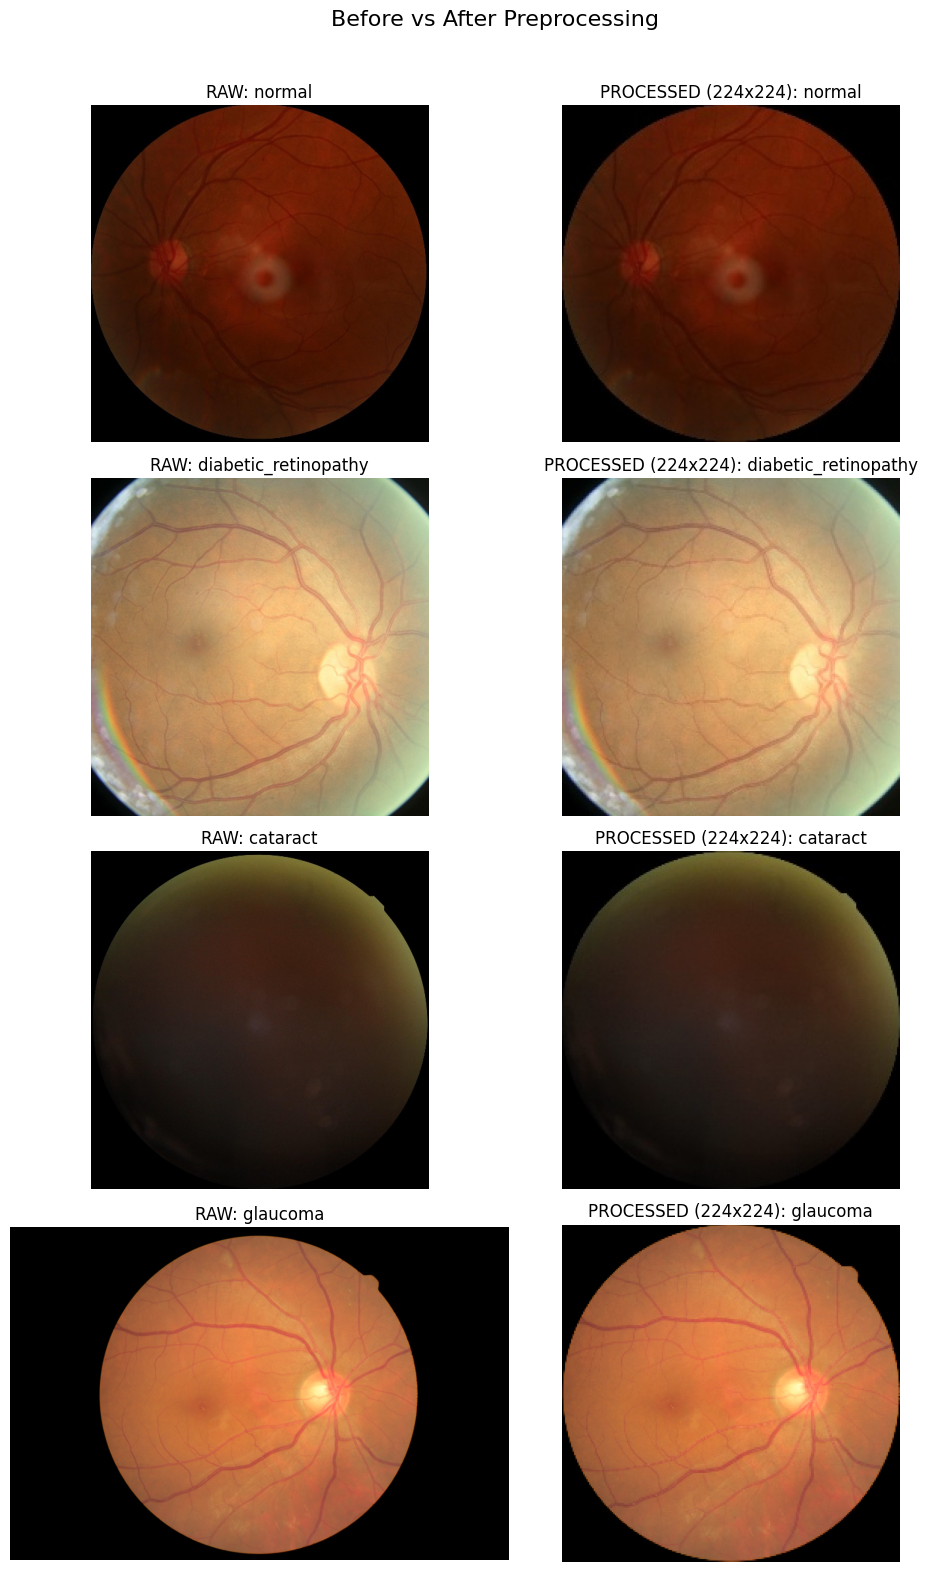

In [2]:
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(10, 4 * len(CLASSES)))
fig.suptitle('Before vs After Preprocessing', fontsize=16)

for idx, cls in enumerate(CLASSES):
    raw_cls_dir = os.path.join(RAW_DIR, cls)
    proc_cls_dir = os.path.join(PROCESSED_DIR, cls)
    
    if not os.path.exists(raw_cls_dir) or not os.path.exists(proc_cls_dir):
        continue
        
    raw_images = glob.glob(os.path.join(raw_cls_dir, '*.*'))
    if len(raw_images) == 0:
        continue
        
    # Select one random image that exists in both
    random_raw_path = random.choice(raw_images)
    filename = os.path.basename(random_raw_path)
    # Preprocessing script forces .jpg extension
    proc_filename = filename if filename.lower().endswith(('.jpg', '.jpeg', '.png')) else filename + '.jpg'
    proc_path = os.path.join(proc_cls_dir, proc_filename)
    
    # Read Raw
    raw_img = cv2.imread(random_raw_path)
    if raw_img is not None:
        raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        axes[idx, 0].imshow(raw_img_rgb)
        axes[idx, 0].set_title(f'RAW: {cls}')
        axes[idx, 0].axis('off')
        
    # Read Processed
    if os.path.exists(proc_path):
        proc_img = cv2.imread(proc_path)
        if proc_img is not None:
            proc_img_rgb = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)
            axes[idx, 1].imshow(proc_img_rgb)
            axes[idx, 1].set_title(f'PROCESSED (224x224): {cls}')
            axes[idx, 1].axis('off')
    else:
        axes[idx, 1].set_title('Processed file not found')
        axes[idx, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()